In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits

import umap
%matplotlib inline

/Users/lap/.pyenv/versions/3.10.16/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
penguins = pd.read_csv(
    "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins.csv"
)
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
penguins = penguins.dropna()
penguins.species.value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

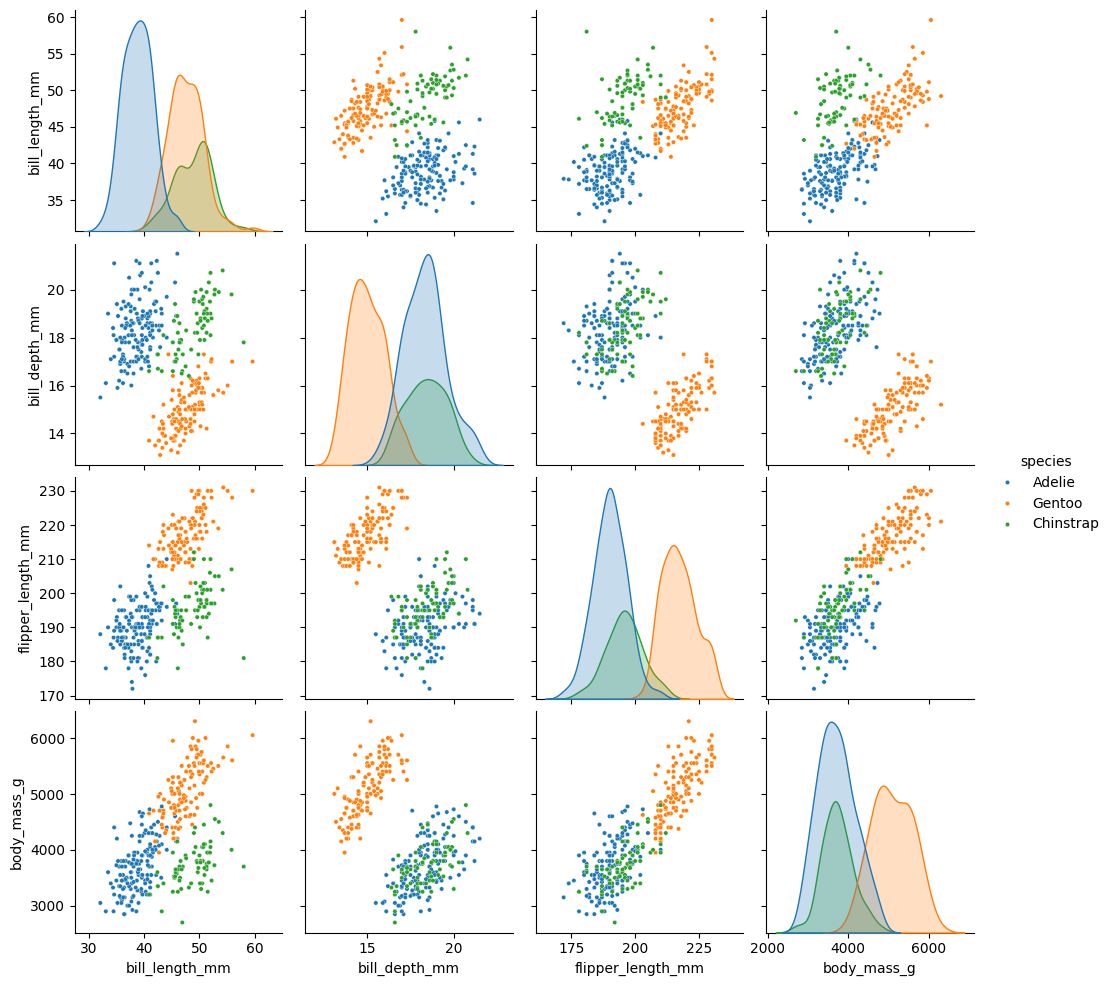

In [4]:
sns.pairplot(penguins.drop("year", axis=1), hue="species", plot_kws={"s": 10}).savefig(
    "penguins_pairplot.svg", format="svg"
)

In [ ]:
reducer = umap.UMAP()
penguin_data = penguins[
    [
        "bill_length_mm",  # 嘴巴长度
        "bill_depth_mm",  # 嘴深度
        "flipper_length_mm",  # 脚长度
        "body_mass_g",  # 体重
    ]
].values
scaled_penguin_data = StandardScaler().fit_transform(penguin_data)

In [6]:
embedding = reducer.fit_transform(scaled_penguin_data)
embedding.shape

/Users/lap/.pyenv/versions/3.10.16/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(333, 2)

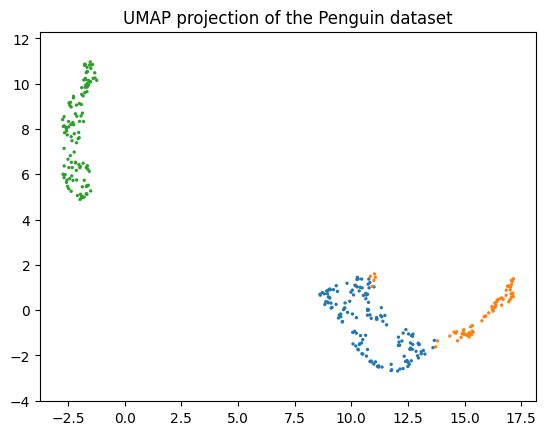

In [7]:
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=2,
    c=[
        sns.color_palette()[x]
        for x in penguins.species.map({"Adelie": 0, "Chinstrap": 1, "Gentoo": 2})
    ],
)
plt.gca().set_aspect("equal", "datalim")
plt.title("UMAP projection of the Penguin dataset")
plt.savefig("./penguins_umap.svg", format="svg")
plt.show()
plt.close()

In [8]:
# 1797 samples, 64 features,
# every feature is an integer from 0 to 16
digits = load_digits()
print(digits.DESCR)
print(digits.data.shape)
pd.DataFrame(digits.data)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


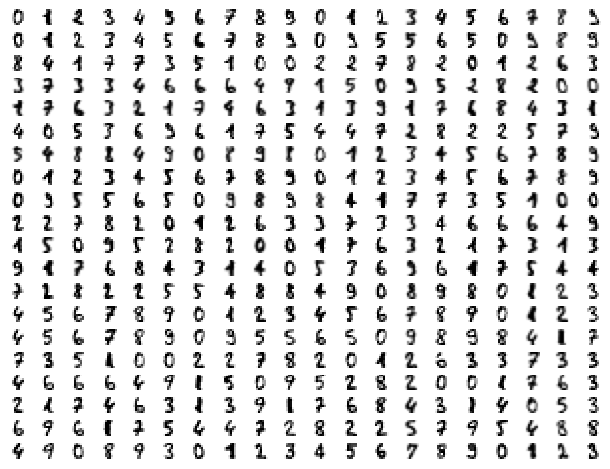

In [9]:
fig, ax_array = plt.subplots(20, 20)
axes = ax_array.flatten()
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray_r")
plt.setp(axes, xticks=[], yticks=[], frame_on=False)
plt.tight_layout(h_pad=0.5, w_pad=0.01)
plt.savefig("./digits.svg", format="svg")
plt.show()
plt.close()

In [10]:
# kind_dict = { i: f"{i}"for }
digits_df = pd.DataFrame(digits.data[:, 1:11])
digits_df["digit"] = pd.Series(digits.target).map(lambda x: "Digit {}".format(x))
digits_df.head(n=11)

,0,1,2,3,4,5,6,7,8,9,digit
0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,Digit 0
1,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,Digit 1
2,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,Digit 2
3,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,Digit 3
4,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,Digit 4
5,0.0,12.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,Digit 5
6,0.0,0.0,12.0,13.0,0.0,0.0,0.0,0.0,0.0,5.0,Digit 6
7,0.0,7.0,8.0,13.0,16.0,15.0,1.0,0.0,0.0,7.0,Digit 7
8,0.0,9.0,14.0,8.0,1.0,0.0,0.0,0.0,0.0,12.0,Digit 8
9,0.0,11.0,12.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,Digit 9


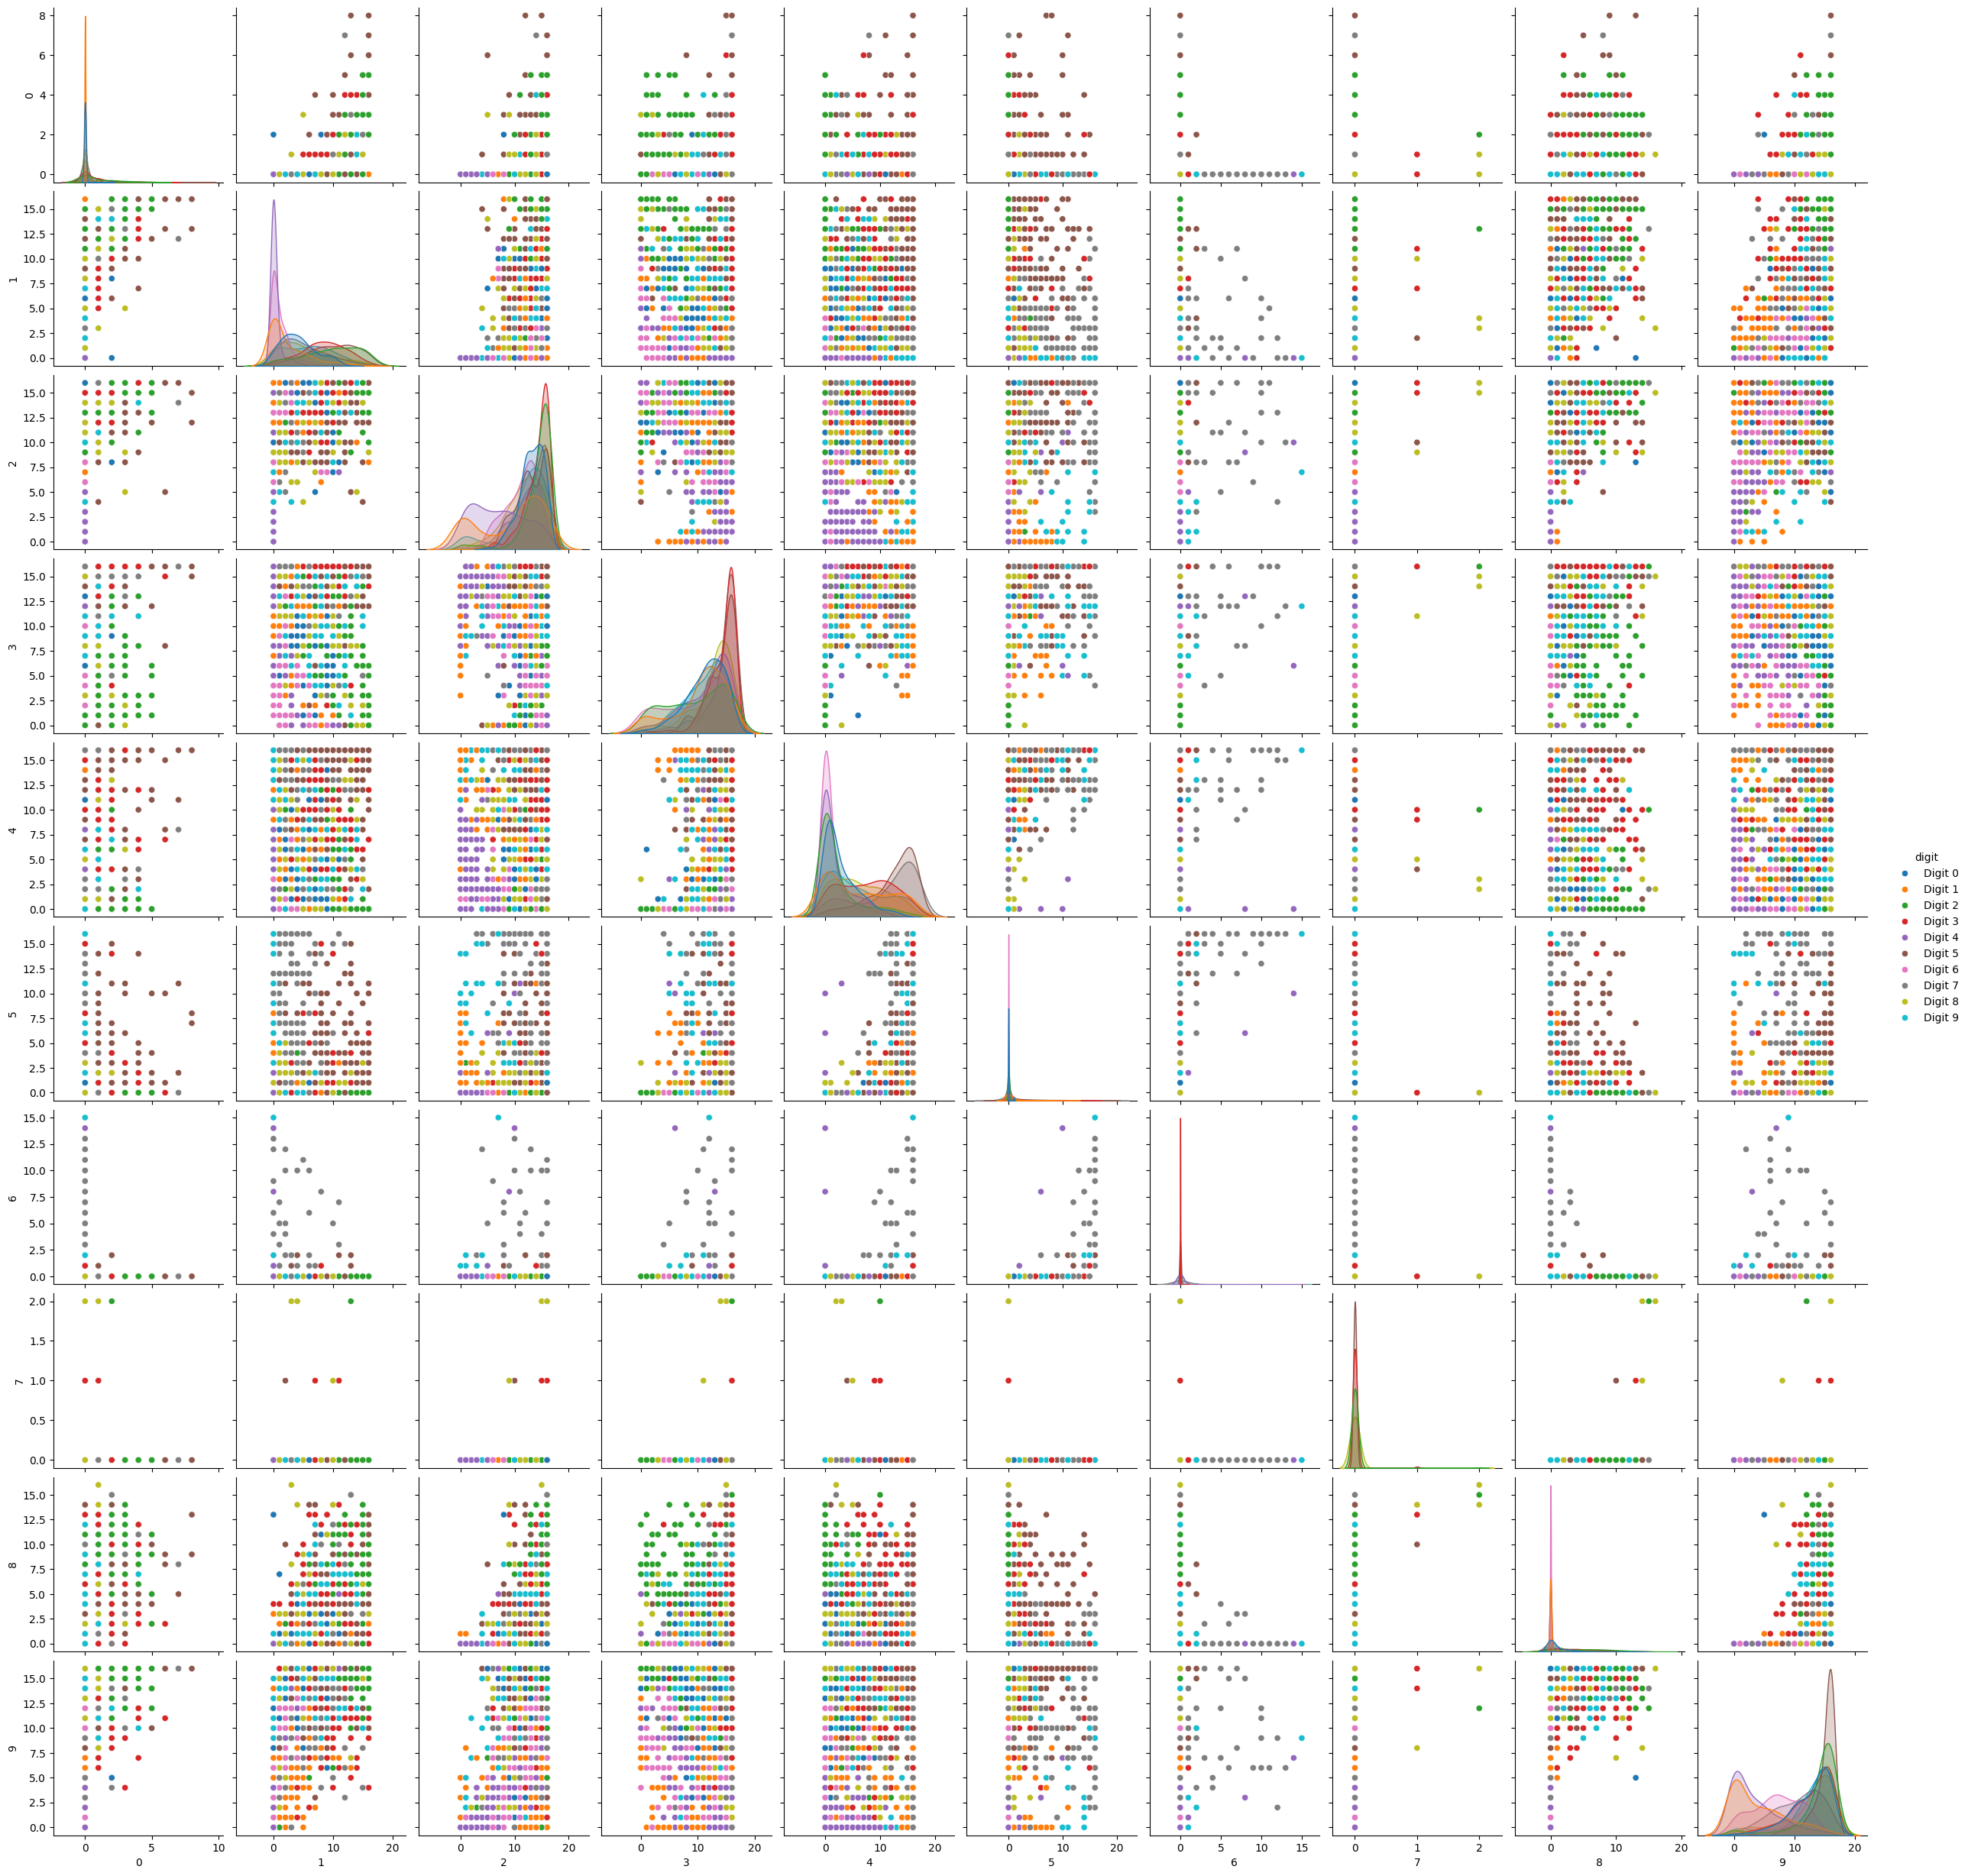

In [11]:
# 非对角线上的图是两两特征之间的散点图 如果散点数很多，重合度高，说明两个特征之间有很强的相关性
sns.pairplot(digits_df, hue="digit").savefig(
    "./digits_pairplot_col1-10.svg", format="svg"
)
# 对角线，例如grid 0,0 (第一列的分布情况，第一列大部分数值都为0)

In [12]:
reducer = umap.UMAP()
reducer.fit(digits.data)

/Users/lap/.pyenv/versions/3.10.16/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP(tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})

In [13]:
embedding = reducer.transform(digits.data)
print(embedding.shape)
print(embedding)
embedding_df = pd.DataFrame(embedding, columns=["x", "y"])
embedding_df["digit"] = pd.Series(digits.target).map(lambda x: "Digit {}".format(x))
embedding_df.head(10)

(1797, 2)
[[15.143681    6.4060197 ]
 [ 0.61969507 12.059936  ]
 [-4.696918    9.293345  ]
 ...
 [-0.1905511   9.352439  ]
 [ 0.88364416  3.2969196 ]
 [-0.09995969  8.782368  ]]


/Users/lap/.pyenv/versions/3.10.16/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,x,y,digit
0,15.143681,6.406020,Digit 0
1,0.619695,12.059936,Digit 1
2,-4.696918,9.293345,Digit 2
3,2.586907,6.400334,Digit 3
4,8.017803,16.188843,Digit 4
5,1.856128,2.575236,Digit 5
6,1.097107,-8.709977,Digit 6
7,0.201627,20.200083,Digit 7
8,-0.182371,8.743268,Digit 8
9,0.886439,3.254767,Digit 9


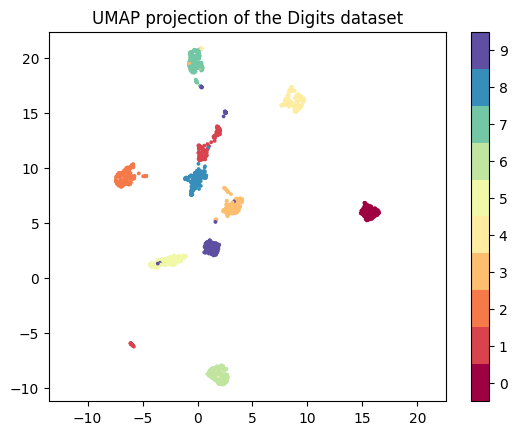

In [14]:
plt.scatter(embedding[:, 0], embedding[:, 1], c=digits.target, cmap='Spectral', s=3)
plt.gca().set_aspect('equal', 'datalim')
plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title('UMAP projection of the Digits dataset');
plt.savefig("./digits_umap.svg", format='svg')
plt.show()
plt.close()

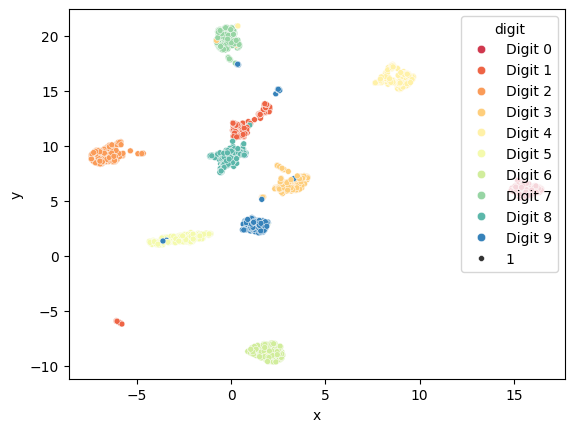

In [15]:
ax = sns.scatterplot(embedding_df, palette="Spectral",hue="digit", x="x", y="y", size=1).plot()
plt.savefig("./digits_umap_sns.svg", format="svg")

In [16]:
from io import BytesIO
from PIL import Image
import base64

In [17]:
def embeddable_image(data):
    img_data = 255 - 15 * data.astype(np.uint8)
    image = Image.fromarray(img_data, mode='L').resize((64, 64), Image.Resampling.BICUBIC)
    buffer = BytesIO()
    image.save(buffer, format='png')
    for_encoding = buffer.getvalue()
    return 'data:image/png;base64,' + base64.b64encode(for_encoding).decode()

%pip install bokeh
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import HoverTool, ColumnDataSource, CategoricalColorMapper
from bokeh.palettes import Spectral10

output_notebook()

Note: you may need to restart the kernel to use updated packages.


Loading BokehJS ...

In [18]:
digits_df = pd.DataFrame(embedding, columns=('x', 'y'))
digits_df['digit'] = [str(x) for x in digits.target]
digits_df['image'] = list(map(embeddable_image, digits.images))

datasource = ColumnDataSource(digits_df)
color_mapping = CategoricalColorMapper(factors=[str(9 - x) for x in digits.target_names],
                                       palette=Spectral10)

plot_figure = figure(
    title='UMAP projection of the Digits dataset',
    width=600,
    height=600,
    tools=('pan, wheel_zoom, reset')
)

plot_figure.add_tools(HoverTool(tooltips="""
<div>
    <div>
        <img src='@image' style='float: left; margin: 5px 5px 5px 5px'/>
    </div>
    <div>
        <span style='font-size: 16px; color: #224499'>Digit:</span>
        <span style='font-size: 18px'>@digit</span>
    </div>
</div>
"""))

plot_figure.circle(
    'x',
    'y',
    source=datasource,
    color=dict(field='digit', transform=color_mapping),
    line_alpha=0.6,
    fill_alpha=0.6,
    size=4
)
show(plot_figure)